In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data = pd.read_csv("data/processed/cleaned_data.csv")

In [ ]:
df = pd.DataFrame(data)

# 🌍 Advanced Exploratory Data Analysis (EDA)
### Environment, Urbanization, and Public Health

This notebook performs:
- Feature Engineering
- Correlation Analysis
- Statistical Relationships
- Urban Impact Visualization
- City-Level Deep Dive

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0}) # Suppress warnings for many plots

print("=== STARTING ADVANCED EXPLORATORY DATA ANALYSIS ===\n")

=== STARTING ADVANCED EXPLORATORY DATA ANALYSIS ===



In [ ]:
# Format city and country names to proper case in the main DataFrame
df['City'] = df['City'].str.title()
df['Country'] = df['Country'].str.title()

## 1. Feature Engineering

We construct composite indicators to better capture real-world dynamics:

- Net_Forestation_% represents the true balance between afforestation and deforestation.
- Urban_Stress_Index captures combined pressure from population density, vehicles, and industrial growth.

In [ ]:
# Net forestation shows the actual balance of tree cover changes
df['Net_Forestation_%'] = df['Afforestation_Rate_%'] - df['Deforestation_Rate_%']

# Urban stress combines density with the growth of vehicles and industry
df['Urban_Stress_Index'] = df['Population_Density_Per_SqKm'] * ((df['Vehicles_Increase_%'] + df['Industries_Increase_%']) / 100)

## 2. Correlation Analysis

We analyze relationships between environmental, economic, and health variables using a correlation heatmap.

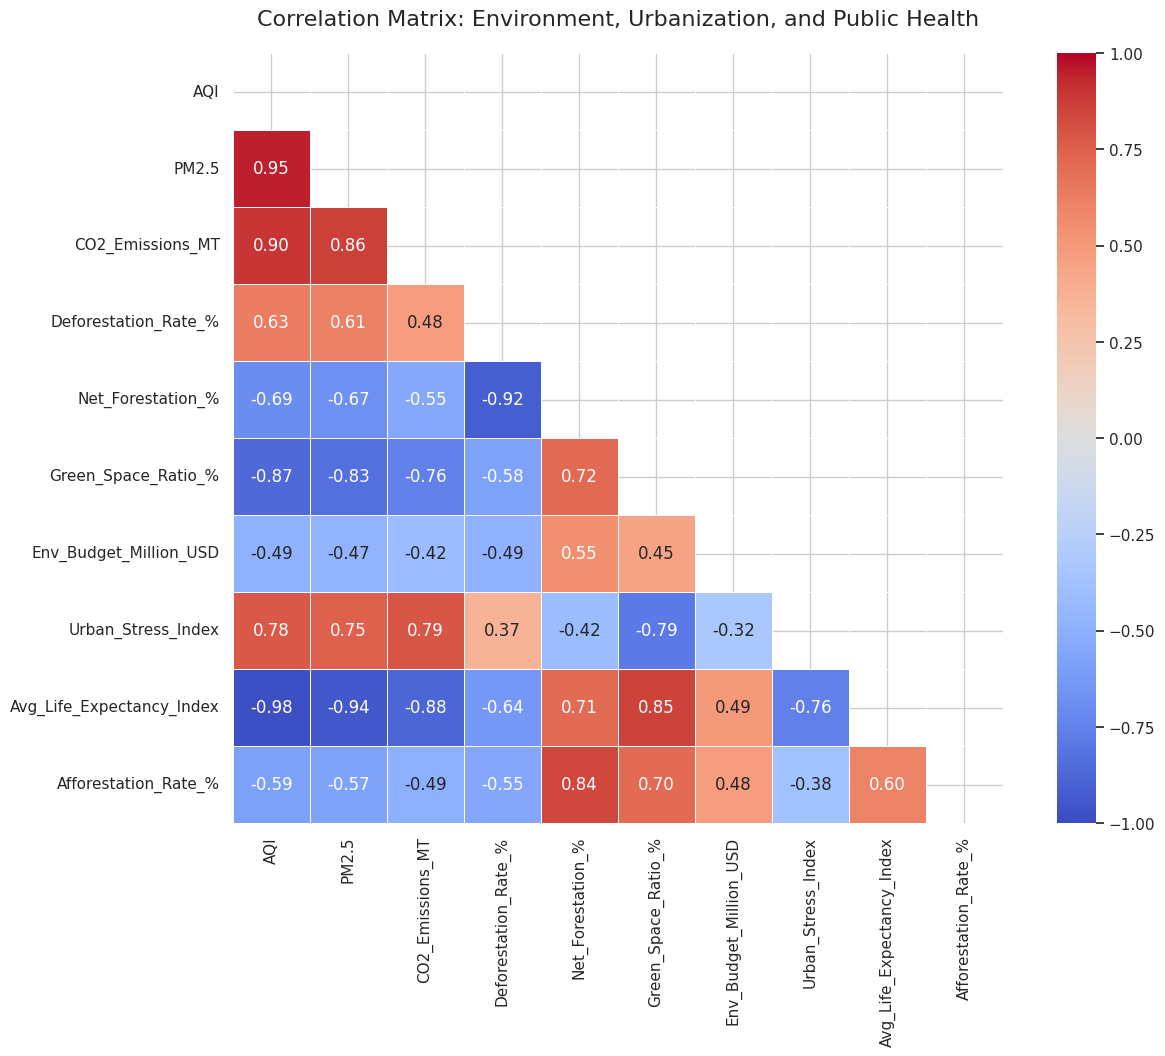

In [ ]:
plt.figure(figsize=(14, 10))

target_cols = [
    'AQI', 'PM2.5', 'CO2_Emissions_MT',
    'Deforestation_Rate_%', 'Net_Forestation_%', 'Green_Space_Ratio_%',
    'Env_Budget_Million_USD', 'Urban_Stress_Index', 'Avg_Life_Expectancy_Index',"Afforestation_Rate_%"
]

corr_matrix = df[target_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=.5
)

plt.title("Correlation Matrix: Environment, Urbanization, and Public Health", fontsize=16, pad=20)
plt.show()

## 3. Environmental Spending vs Air Quality

We examine whether higher environmental budgets are associated with better air quality using regression analysis and statistical correlation.

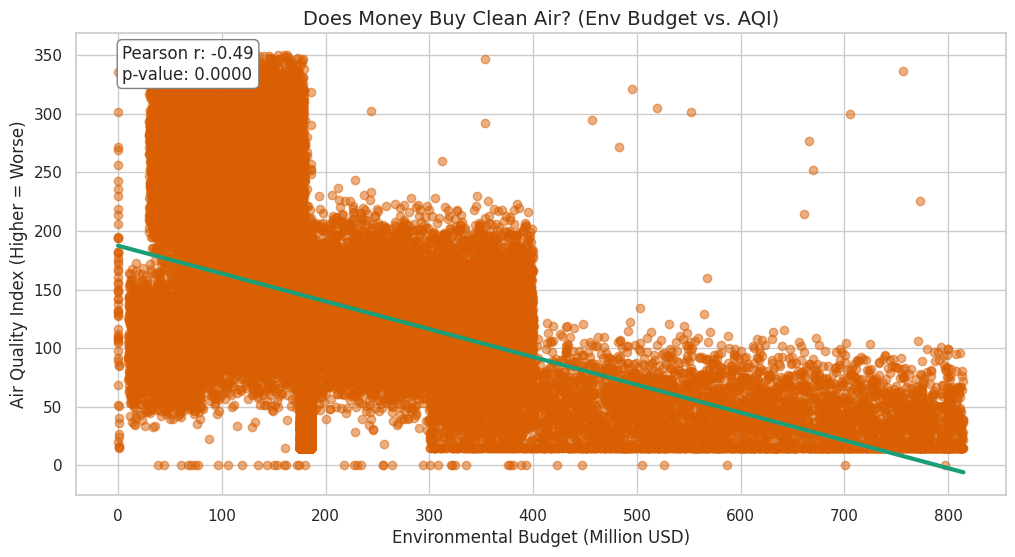

In [ ]:
plt.figure(figsize=(12, 6))

sns.regplot(
    data=df,
    x='Env_Budget_Million_USD',
    y='AQI',
    scatter_kws={'alpha':0.5, 'color':'#d95f02'},
    line_kws={'color':'#1b9e77', 'lw':3}
)

plt.title("Does Money Buy Clean Air? (Env Budget vs. AQI)", fontsize=14)
plt.xlabel("Environmental Budget (Million USD)")
plt.ylabel("Air Quality Index (Higher = Worse)")

valid_data = df[['Env_Budget_Million_USD', 'AQI']].dropna()
r, p = stats.pearsonr(valid_data['Env_Budget_Million_USD'], valid_data['AQI'])

plt.annotate(
    f'Pearson r: {r:.2f}\np-value: {p:.4f}',
    xy=(0.05, 0.9),
    xycoords='axes fraction',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1)
)

plt.show()

## 4. Urbanization, Environment, and Public Health

Two perspectives are explored:

- Relationship between green space, pollution, and life expectancy
- Impact of urban stress on CO2 emissions, adjusted for forestation levels

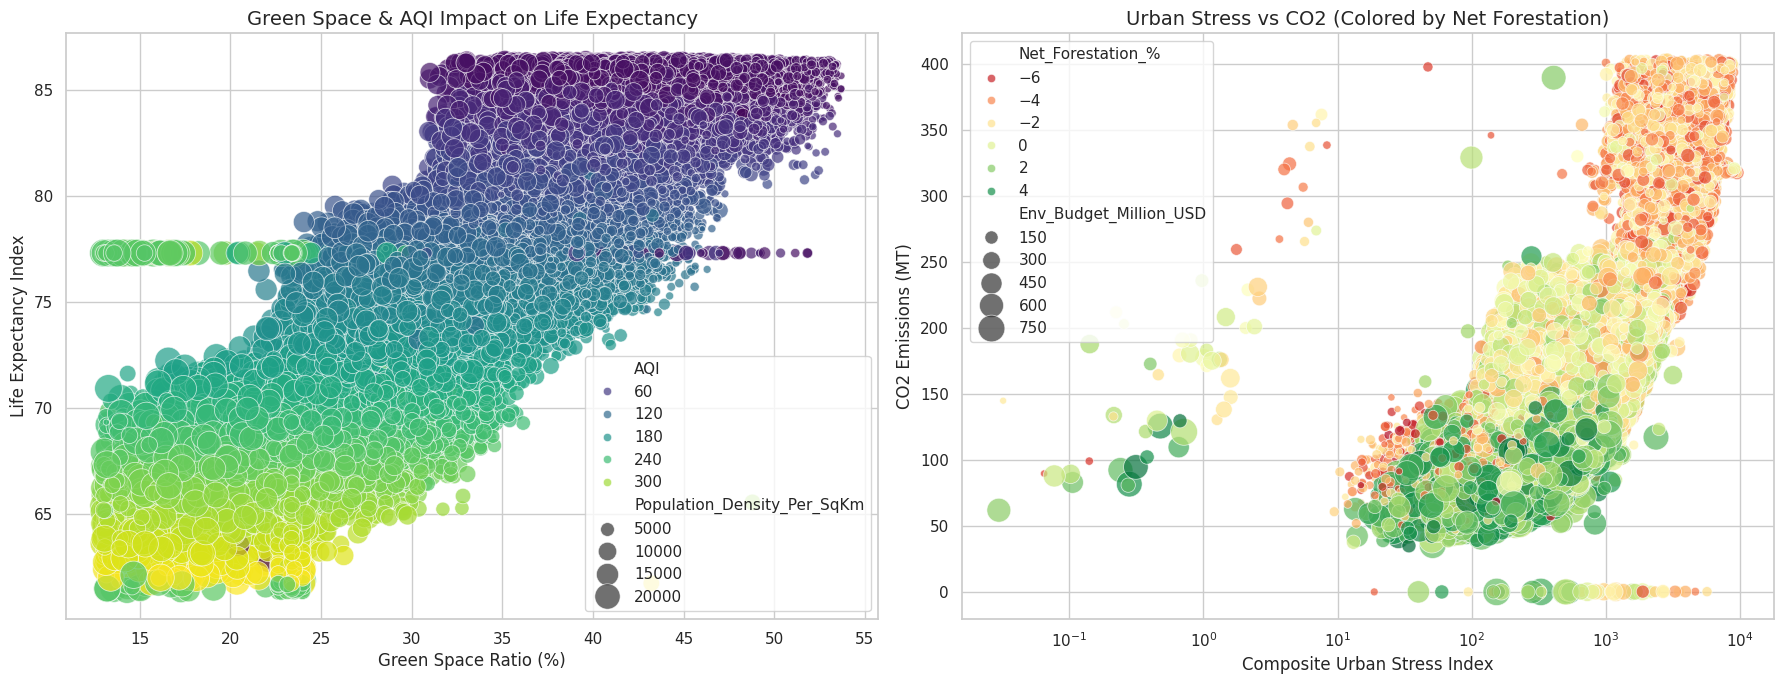

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot A
sns.scatterplot(
    data=df,
    x='Green_Space_Ratio_%',
    y='Avg_Life_Expectancy_Index',
    size='Population_Density_Per_SqKm',
    hue='AQI',
    palette='viridis',
    sizes=(20, 400),
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("Green Space & AQI Impact on Life Expectancy", fontsize=14)
axes[0].set_xlabel("Green Space Ratio (%)")
axes[0].set_ylabel("Life Expectancy Index")

# Plot B
sns.scatterplot(
    data=df,
    x='Urban_Stress_Index',
    y='CO2_Emissions_MT',
    hue='Net_Forestation_%',
    palette='RdYlGn',
    size='Env_Budget_Million_USD',
    sizes=(20, 400),
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title("Urban Stress vs CO2 (Colored by Net Forestation)", fontsize=14)
axes[1].set_xlabel("Composite Urban Stress Index")
axes[1].set_ylabel("CO2 Emissions (MT)")
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

## 5. City-Level Analysis

We identify the cities with the worst air quality and examine their environmental budgets and urban stress levels.

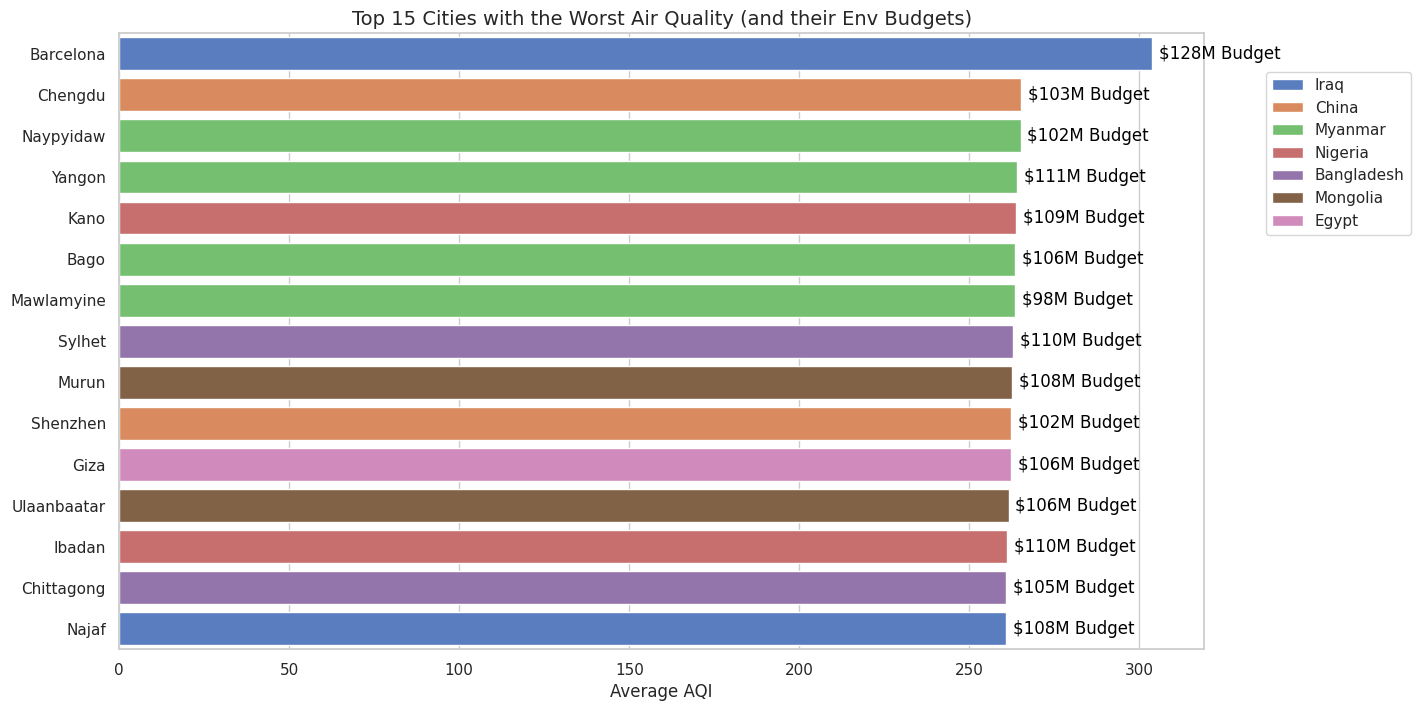

In [ ]:
worst_cities = df.groupby(['City', 'Country']).agg({
    'AQI': 'mean',
    'PM2.5': 'mean',
    'Urban_Stress_Index': 'mean',
    'Env_Budget_Million_USD': 'mean'
}).sort_values(by='AQI', ascending=False).head(15).reset_index()

plt.figure(figsize=(14, 8))

ax1 = sns.barplot(data=worst_cities, x='AQI', y='City', hue= 'Country')

ax1.set_title("Top 15 Cities with the Worst Air Quality (and their Env Budgets)", fontsize=14)
ax1.set_xlabel("Average AQI")

ax1.set_ylabel("")

for index, row in worst_cities.iterrows():
    ax1.text(row['AQI'] + 2, index, f"${row['Env_Budget_Million_USD']:.0f}M Budget", color='black', va="center")
plt.legend(bbox_to_anchor=(1.05, 0.95))
plt.show()

## AQI vs Deforestation vs Green Space

This scatter plot shows how AQI relates to deforestation and green space.
Color represents Green Space Ratio to capture environmental balance.


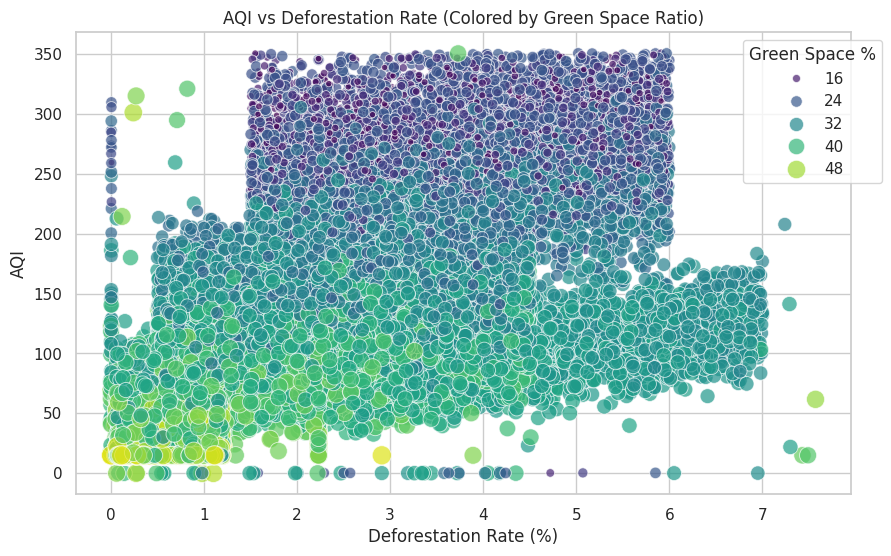

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Deforestation_Rate_%',
    y='AQI',
    hue='Green_Space_Ratio_%',
    palette='viridis',
    size='Green_Space_Ratio_%',
    sizes=(20, 200),
    alpha=0.7
)

plt.title("AQI vs Deforestation Rate (Colored by Green Space Ratio)")
plt.xlabel("Deforestation Rate (%)")
plt.ylabel("AQI")
plt.legend(title="Green Space %", bbox_to_anchor=(1.05, 1))
plt.show()

## Life Expectancy in Top 15 Most Polluted Cities

We analyze life expectancy trends among cities with the worst AQI levels.


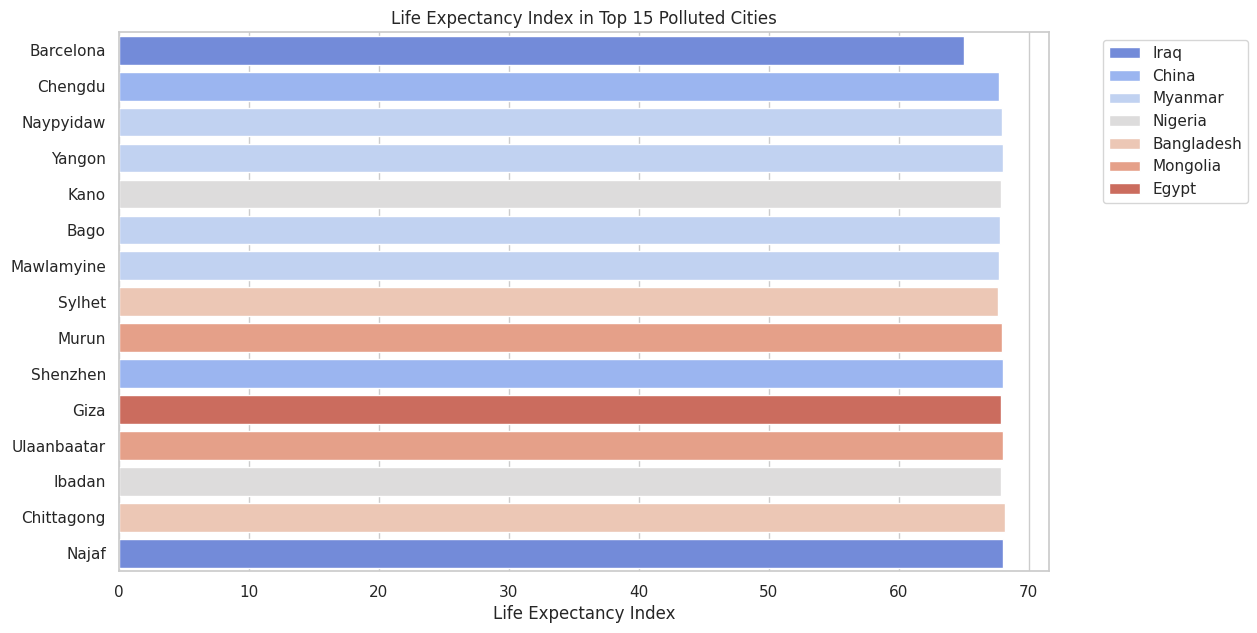

In [ ]:
top_polluted = df.groupby(['City', 'Country']).agg({
    'AQI': 'mean',
    'Avg_Life_Expectancy_Index': 'mean'
}).sort_values(by='AQI', ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_polluted,
    x='Avg_Life_Expectancy_Index',
    y='City',
    palette='coolwarm',
    hue='Country'
)

plt.title("Life Expectancy Index in Top 15 Polluted Cities")
plt.xlabel("Life Expectancy Index")
plt.ylabel("")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

## Vehicle Growth in Top 15 Cities

This plot shows vehicle increase in major cities.
Color is used to differentiate countries.


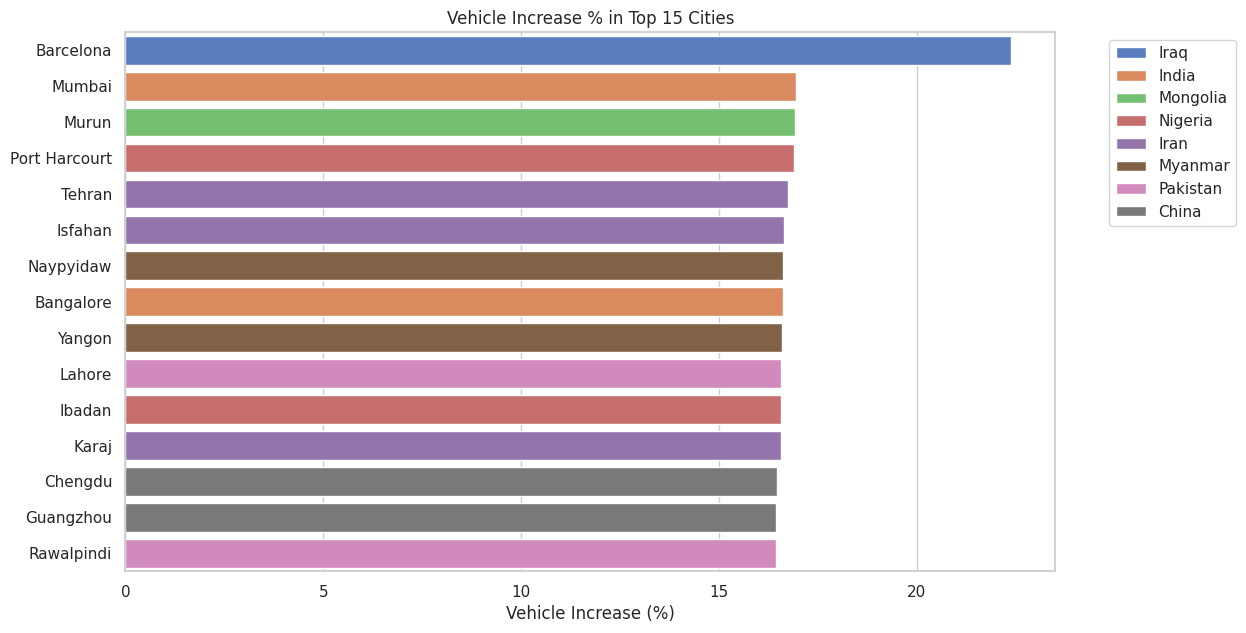

In [ ]:
top_cities_vehicle = df.groupby(['City', 'Country']).agg({
    'Vehicles_Increase_%': 'mean'
}).sort_values(by='Vehicles_Increase_%', ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_cities_vehicle,
    x='Vehicles_Increase_%',
    y='City',
    hue='Country'
)

plt.title("Vehicle Increase % in Top 15 Cities")
plt.xlabel("Vehicle Increase (%)")
plt.ylabel("")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

## Global Life Expectancy Choropleth

A world map showing life expectancy distribution across countries.

In [ ]:
import plotly.express as px

country_life = df.groupby('Country').agg({
    'Avg_Life_Expectancy_Index': 'mean'
}).reset_index()

fig = px.choropleth(
    country_life,
    locations='Country',
    locationmode='country names',
    color='Avg_Life_Expectancy_Index',
    color_continuous_scale='Viridis',
    title='Global Life Expectancy Index by Country'
)

fig.show()

## Global Average AQI by Country

This choropleth map visualizes average AQI levels globally.

In [ ]:
country_aqi = df.groupby('Country').agg({
    'AQI': 'mean'
}).reset_index()

fig = px.choropleth(
    country_aqi,
    locations='Country',
    locationmode='country names',
    color='AQI',
    color_continuous_scale='Reds',
    title='Global Average AQI by Country'
)

fig.show()